In [2]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure


In [3]:
preds_dir = '../preds/'
dataset_dir = '../data/all_years_merged_era5.nc'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)


[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [4]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)

def get_original_temperature(data, scale):
    t_min = scale['t2m']['min'].item()
    t_max = scale['t2m']['max'].item()
    
    norm_t = data[:,2,:,:]
    
    t = norm_t * (t_max - t_min) + t_min

    return t
    
def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)

def kelvin_to_celsius(data):
    return data - 273.15

In [5]:
def get_ground_truth_temp(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_temp= test_split['t2m'].values    
    return test_split, gt_temp, scale

eval_split, ground_truth_temp, scale = get_ground_truth_temp(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


In [6]:
def get_low_res_temp(test_data, scaling_factor):
    u10, v10 = [], []
    temp = []
    for i in range(test_data['u10'].shape[0]):
        temp.append(average_pooling(test_data['t2m'][i].values, scaling_factor, False))
    return np.array(temp)

lr_temp = get_low_res_temp(eval_split, SCALING_FACTOR)


In [7]:
def get_temp_fields(files_dir, scaling_factor, year, normalization_scale,lr_temp, gt_temp):
    files = os.listdir(files_dir)
    temp_fields = [lr_temp, gt_temp]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        field = torch.load(files_dir + file, weights_only=False)
            
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            
            baseline = get_original_temperature(field, normalization_scale)
            names.append("Bicubic Interpolation")
            temp_fields.append(baseline)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            names.append("EDSR")
            edsr = get_original_temperature(field, normalization_scale)
            temp_fields.append(edsr)
    return temp_fields, names


475


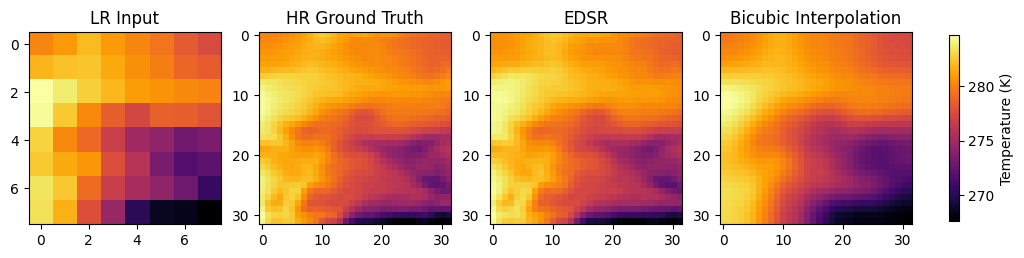

In [ ]:
longitudes = eval_split['longitude'].values[:32]
latitudes = eval_split['latitude'].values[:32]
def plot_comparison(fields, names, index, to_celcius = False):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(15, 8))
    fields = [field[index] for field in fields]
    fields = [kelvin_to_celsius(field) for field in fields] if to_celcius else fields
    temp_label = 'Temperature (C)' if to_celcius else 'Temperature (K)'
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[-1], latitudes[0], 5)
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='inferno')
        else:
            ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))
        ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks])
        ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks])
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label(f'{temp_label}')  
    #plt.suptitle(f"Wind Speed Comparison - {TEST_YEAR}", fontsize=14, y=.75)
    plt.show()

temp_fields, names = get_temp_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scale=scale, 
                                        lr_temp=lr_temp, 
                                        gt_temp=ground_truth_temp)
index = np.random.randint(0, len(ground_truth_temp))
print(index)
plot_comparison(temp_fields, names, index, to_celcius=False)

In [ ]:

temp_dict = {year: {} for year in years}
for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_temp(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_temp(eval_split, SCALING_FACTOR)
        temp_fields, names = get_temp_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_temp=lr_temp, 
                                                gt_temp=ground_truth_temp)
        
        edsr = temp_fields[names.index('EDSR')]
        baseline = temp_fields[names.index('Bicubic Interpolation')]
        temp_dict[year]['EDSR'] = edsr
        temp_dict[year]['Baseline'] = baseline
        temp_dict[year]['Ground Truth'] = ground_truth_wind_speeds


In [ ]:
def get_metrics_over_time(years):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
    mse_skill_scores = []
    mae_skill_scores = []
    for year in years:
        edsr = temp_dict[year]['EDSR']
        baseline = temp_dict[year]['Baseline']
        ground_truth_wind_speeds = temp_dict[year]['Ground Truth']
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        
        maes['Bicubic'].append(mae_baseline)
        
    return mses, maes, mse_skill_scores, mae_skill_scores



def plot_metrics_over_time(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    
    for i, model in enumerate(mses):
        # Plot MSE for the current model
        ax[i, 0].plot(years, mses[model], 'o-', label=f"{model} - MSE", color='blue')
        ax[i, 0].set_title(f'{model} - MSE')
        ax[i, 0].set_xlabel('Year')
        ax[i, 0].set_ylabel('MSE')
        ax[i, 0].legend()
        ax[i, 0].grid(True)

        # Plot MAE for the current model
        ax[i, 1].plot(years, maes[model], 'o-', label=f"{model} - MAE", color='orange')
        ax[i, 1].set_title(f'{model} - MAE')
        ax[i, 1].set_xlabel('Year')
        ax[i, 1].set_ylabel('MAE')
        ax[i, 1].legend()
        ax[i, 1].grid(True)

    plt.tight_layout()
    plt.show()
    
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].plot(years, mse_ss, 'o-', label='MSE Skill Score', color='blue')
    ax[0].set_title('MSE Skill Score')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, 'o-', label='MAE Skill Score', color='orange')
    ax[1].set_title('MAE Skill Score')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()
    

In [ ]:
mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

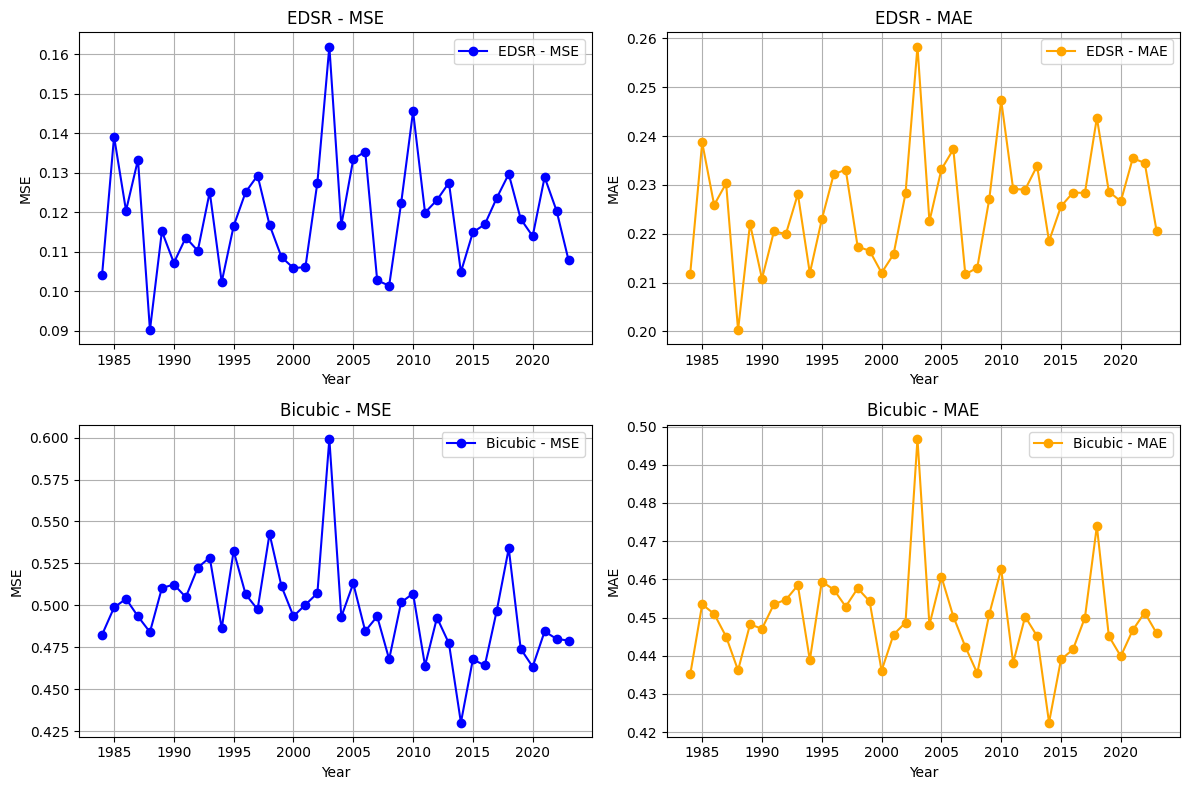

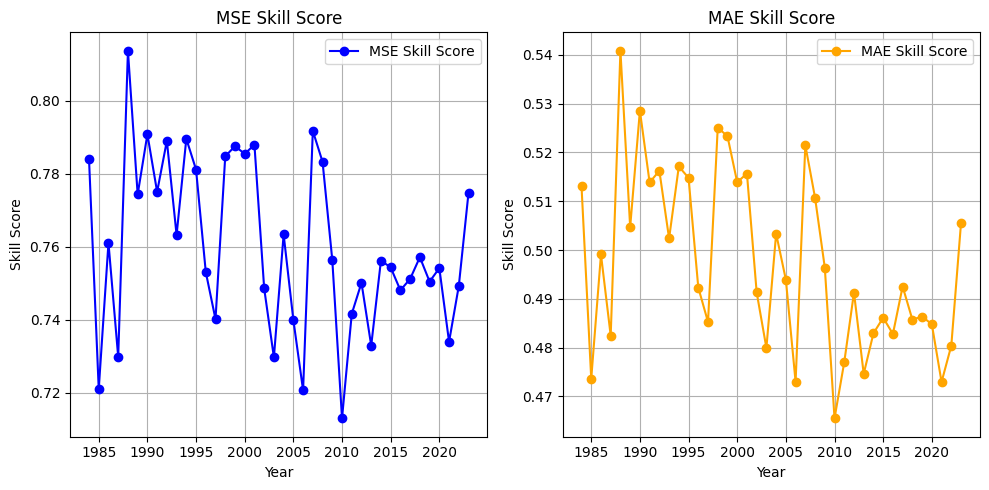

In [ ]:
plot_metrics_over_time(years, mses, maes)
plot_skill_scores(years, mse_skill_scores, mae_skill_scores)